[INFO] Environment setup complete
  RAW_DIR       : C:\Users\User\Downloads\학술\9_ai거버넌스_챗봇_ssci\financial_ai_governance\data\raw
  PROCESSED_DIR : C:\Users\User\Downloads\학술\9_ai거버넌스_챗봇_ssci\financial_ai_governance\data\processed
  [LOAD] nist_dataset_001_050.json                          →  50 records
  [LOAD] nist_dataset_051_100.json                          →  50 records
  [LOAD] kr_aibasicact_dataset_101_150.json                 →  50 records
  [LOAD] kr_aibasicact_dataset_151_200.json                 →  50 records
  [LOAD] eu_aiact_dataset_201_250.json                      →  50 records
  [LOAD] eu_aiact_dataset_251_300.json                      →  50 records

[INFO] Merge complete: 300 records, 15 columns
[OK] All required columns present
[OK] No missing values
[OK] Duplicate IDs: 0

[INFO] ID range     : Q001 ~ Q300
[INFO] Regulations  : ['NIST_AI_RMF', 'KR_AI_BASIC_ACT', 'EU_AI_ACT']
  DATASET OVERVIEW  (N=300)

[1] Regulation Distribution
  NIST AI RMF              : 100 (33.

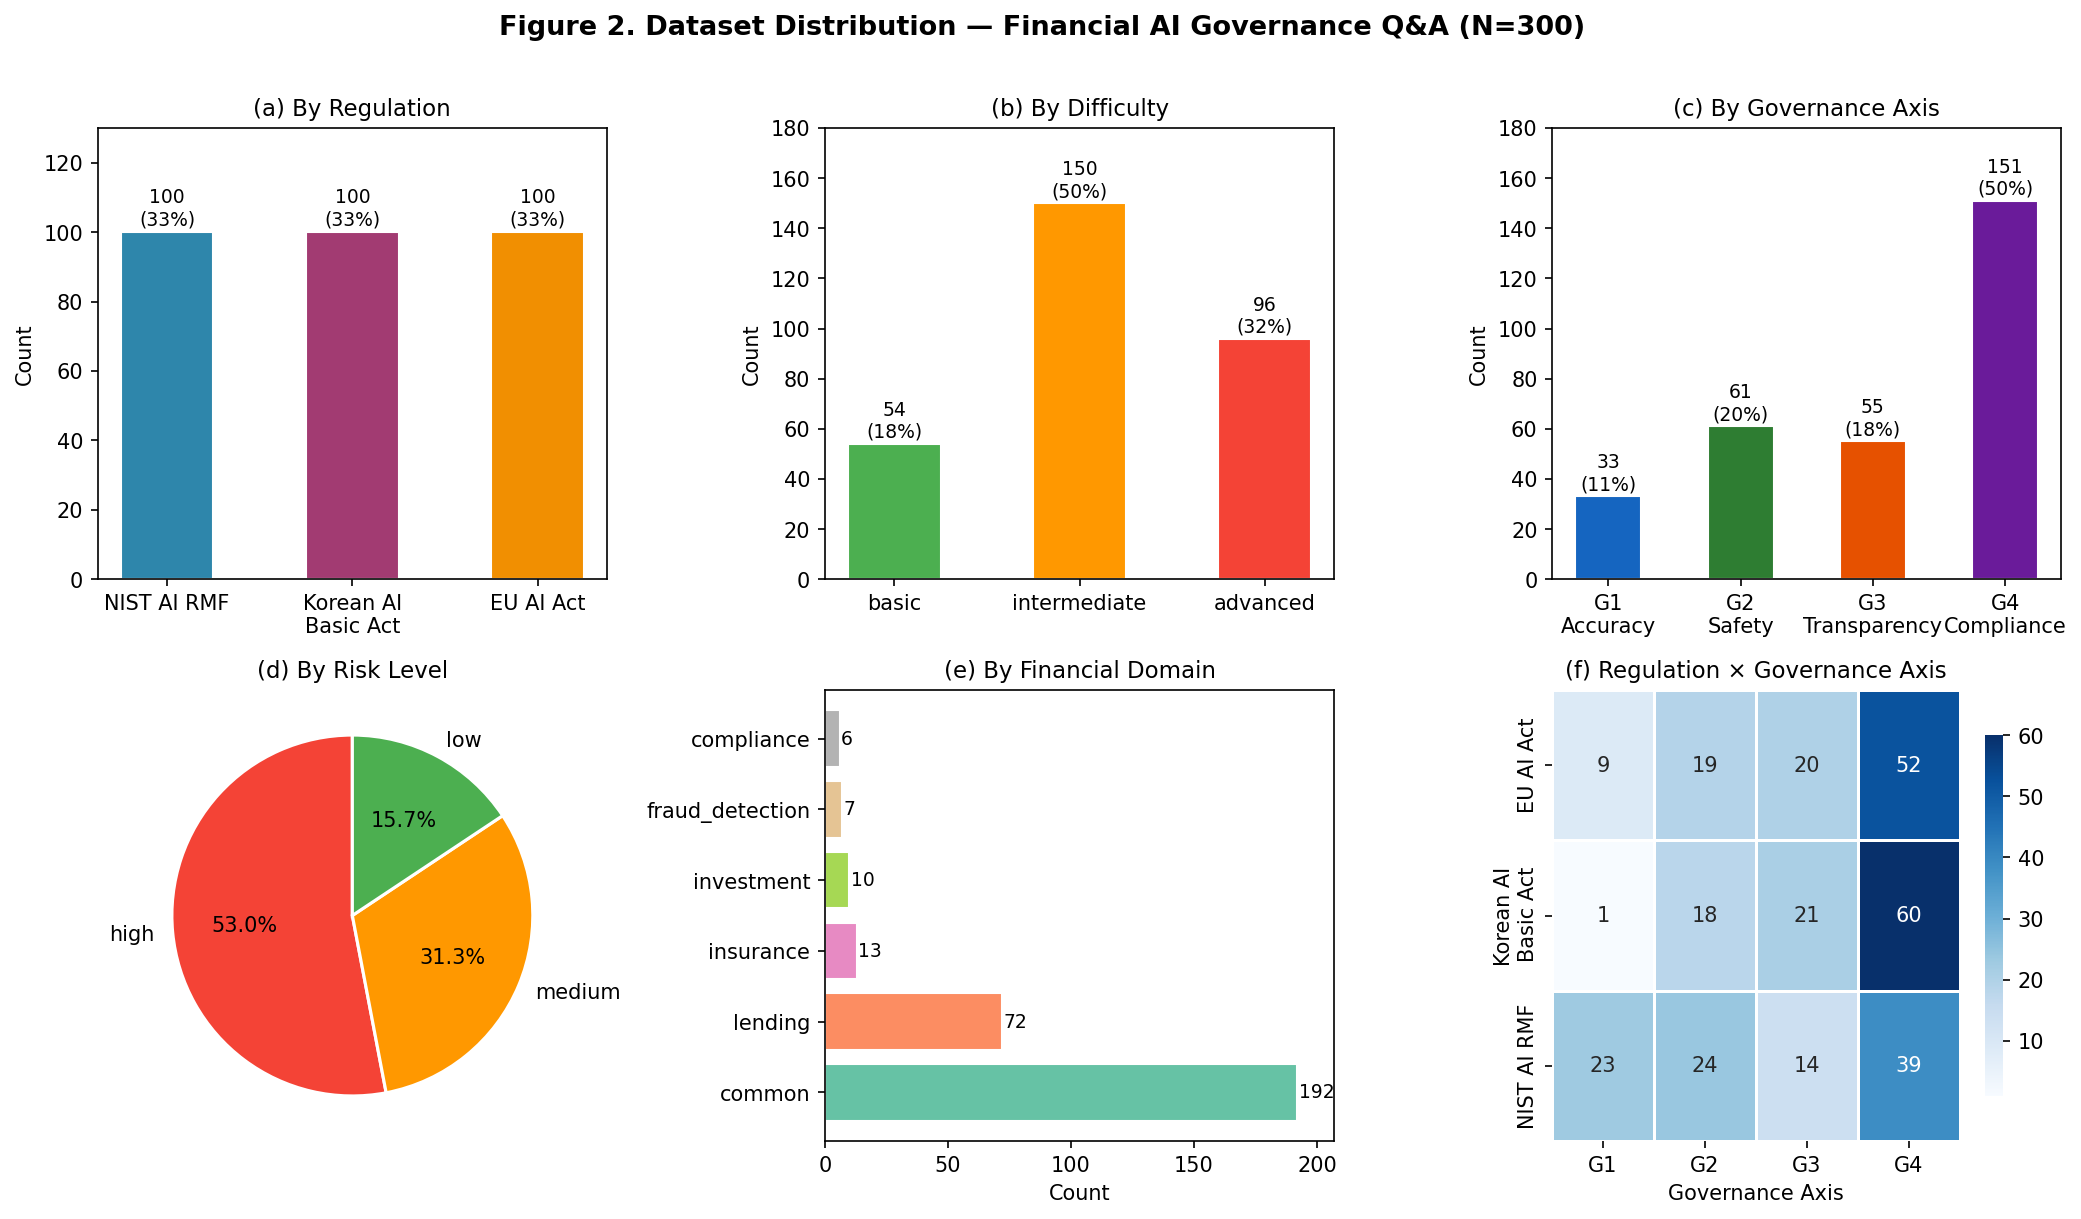

[SAVE] ../results/figures\fig02_dataset_distribution.png
[Table 2] Dataset Statistics
         Regulation   N Basic (%) Intermediate (%) Advanced (%)  G1  G2  G3  G4 High Risk (%) Avg Q Len (chars) Avg GT Len (chars)
        NIST AI RMF 100  18 (18%)         47 (47%)     35 (35%)  23  24  14  39      52 (52%)               193               1308
Korean AI Basic Act 100  21 (21%)         51 (51%)     28 (28%)   1  18  21  60      48 (48%)               216               1597
          EU AI Act 100  15 (15%)         52 (52%)     33 (33%)   9  19  20  52      59 (59%)               215               1882
              Total 300  54 (18%)        150 (50%)     96 (32%)  33  61  55 151     159 (53%)               208               1596

[SAVE] ../results/tables\table2_dataset_stats.csv
[SAVE] dataset_final.json  (700 KB)
[SAVE] dataset_final.csv   (611 KB)

✅ Notebook 01 complete — Next: 02_rag_pipeline.ipynb


In [3]:
# %%
# =============================================================================
# 01_data_merge_and_eda.ipynb
# Financial AI Governance — Dataset Merge & Exploratory Data Analysis
# Kernel : Python (llm_env)
# Input  : data/raw/*.json (6 files, N=300)
# Output : data/processed/dataset_final.json
#          data/processed/dataset_final.csv
#          results/tables/table2_dataset_stats.csv
#          results/figures/fig02_dataset_distribution.png
# =============================================================================

# %%
# =============================================================================
# Cell 1. Libraries and Environment Setup
# =============================================================================
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Directory paths
RAW_DIR       = '../data/raw'
PROCESSED_DIR = '../data/processed'
TABLE_DIR     = '../results/tables'
FIGURE_DIR    = '../results/figures'

for d in [PROCESSED_DIR, TABLE_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

# Plot style for publication
plt.rcParams.update({
    'figure.dpi'     : 150,
    'font.family'    : 'DejaVu Sans',
    'font.size'      : 10,
    'axes.titlesize' : 11,
    'axes.labelsize' : 10,
    'legend.fontsize': 9,
})

print("[INFO] Environment setup complete")
print(f"  RAW_DIR       : {os.path.abspath(RAW_DIR)}")
print(f"  PROCESSED_DIR : {os.path.abspath(PROCESSED_DIR)}")


# %%
# =============================================================================
# Cell 2. Load and Merge JSON Files
# =============================================================================
JSON_FILES = [
    'nist_dataset_001_050.json',
    'nist_dataset_051_100.json',
    'kr_aibasicact_dataset_101_150.json',
    'kr_aibasicact_dataset_151_200.json',
    'eu_aiact_dataset_201_250.json',
    'eu_aiact_dataset_251_300.json',
]

records = []
for fname in JSON_FILES:
    fpath = os.path.join(RAW_DIR, fname)
    with open(fpath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    records.extend(data)
    print(f"  [LOAD] {fname:50s} → {len(data):3d} records")

df = pd.DataFrame(records)
print(f"\n[INFO] Merge complete: {len(df)} records, {df.shape[1]} columns")


# %%
# =============================================================================
# Cell 3. Data Validation
# =============================================================================
REQUIRED_COLS = [
    'id', 'scenario_id', 'regulation', 'function',
    'category', 'subcategory', 'difficulty', 'financial_domain',
    'risk_level', 'source_section', 'question', 'ground_truth',
    'legal_basis', 'governance_axis', 'notes'
]

# Check required columns
missing = [c for c in REQUIRED_COLS if c not in df.columns]
print("[OK] All required columns present" if not missing
      else f"[WARN] Missing columns: {missing}")

# Check null values
null_counts = df[REQUIRED_COLS].isnull().sum()
null_cols   = null_counts[null_counts > 0]
print("[OK] No missing values" if len(null_cols) == 0
      else f"[WARN] Missing values detected:\n{null_cols}")

# Check duplicate IDs
dup = df['id'].duplicated().sum()
print(f"[OK] Duplicate IDs: {dup}" if dup == 0
      else f"[WARN] Duplicate IDs: {dup}")

# Summary
print(f"\n[INFO] ID range     : {df['id'].iloc[0]} ~ {df['id'].iloc[-1]}")
print(f"[INFO] Regulations  : {df['regulation'].unique().tolist()}")


# %%
# =============================================================================
# Cell 4. Descriptive Statistics
# =============================================================================
REG_MAP = {
    'NIST_AI_RMF'      : 'NIST AI RMF',
    'KR_AI_BASIC_ACT'  : 'Korean AI Basic Act',
    'EU_AI_ACT'        : 'EU AI Act',
}

print("=" * 55)
print("  DATASET OVERVIEW  (N=300)")
print("=" * 55)

# By regulation
print("\n[1] Regulation Distribution")
for k, v in df['regulation'].value_counts().items():
    print(f"  {REG_MAP.get(k, k):25s}: {v:3d} ({v/len(df)*100:.1f}%)")

# By difficulty
print("\n[2] Difficulty Distribution")
for lvl in ['basic', 'intermediate', 'advanced']:
    cnt = (df['difficulty'] == lvl).sum()
    print(f"  {lvl:15s}: {cnt:3d} ({cnt/len(df)*100:.1f}%)")

# By financial domain
print("\n[3] Financial Domain Distribution")
for dom, cnt in df['financial_domain'].value_counts().items():
    print(f"  {dom:20s}: {cnt:3d} ({cnt/len(df)*100:.1f}%)")

# By governance axis
print("\n[4] Governance Axis Distribution")
for ax in ['G1', 'G2', 'G3', 'G4']:
    cnt = (df['governance_axis'] == ax).sum()
    print(f"  {ax}: {cnt:3d} ({cnt/len(df)*100:.1f}%)")

# By risk level
print("\n[5] Risk Level Distribution")
for lvl in ['high', 'medium', 'low']:
    cnt = (df['risk_level'] == lvl).sum()
    print(f"  {lvl:10s}: {cnt:3d} ({cnt/len(df)*100:.1f}%)")

# Unique counts
print(f"\n[6] Unique Scenarios : {df['scenario_id'].nunique()}")
print(f"    Unique Functions  : {df['function'].nunique()}")
print(f"    Unique Categories : {df['category'].nunique()}")


# %%
# =============================================================================
# Cell 5. Cross-Tabulation Analysis
# =============================================================================
def fmt_index(ct):
    ct.index = [REG_MAP.get(i, i) for i in ct.index]
    return ct

print("[Regulation × Difficulty]")
print(fmt_index(pd.crosstab(df['regulation'], df['difficulty'],
                            margins=True, margins_name='Total')).to_string())

print("\n[Regulation × Governance Axis]")
print(fmt_index(pd.crosstab(df['regulation'], df['governance_axis'],
                            margins=True, margins_name='Total')).to_string())

print("\n[Regulation × Financial Domain]")
print(fmt_index(pd.crosstab(df['regulation'], df['financial_domain'],
                            margins=True, margins_name='Total')).to_string())


# %%
# =============================================================================
# Cell 6. Text Length Analysis
# =============================================================================
df['q_len']  = df['question'].str.len()
df['gt_len'] = df['ground_truth'].str.len()

print("[Text Length Statistics (characters)]")
stats = df.groupby('regulation')[['q_len', 'gt_len']].agg(['mean', 'min', 'max'])
stats.index = [REG_MAP.get(i, i) for i in stats.index]
print(stats.round(0).to_string())

print(f"\n  Overall avg question length    : {df['q_len'].mean():.0f} chars")
print(f"  Overall avg ground truth length: {df['gt_len'].mean():.0f} chars")


# %%
# =============================================================================
# Cell 7. Visualization — Figure 2 (Publication-Ready)
# =============================================================================
REG_KEYS    = ['NIST_AI_RMF', 'KR_AI_BASIC_ACT', 'EU_AI_ACT']
REG_LABELS  = ['NIST AI RMF', 'Korean AI\nBasic Act', 'EU AI Act']
COLORS_REG  = ['#2E86AB', '#A23B72', '#F18F01']
COLORS_DIFF = ['#4CAF50', '#FF9800', '#F44336']
COLORS_G    = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']
COLORS_RISK = ['#F44336', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(
    'Figure 2. Dataset Distribution — Financial AI Governance Q&A (N=300)',
    fontsize=13, fontweight='bold', y=1.01
)

# (a) By Regulation
ax = axes[0, 0]
cnt = [df[df['regulation'] == k].shape[0] for k in REG_KEYS]
bars = ax.bar(REG_LABELS, cnt, color=COLORS_REG, edgecolor='white', width=0.5)
ax.set_title('(a) By Regulation')
ax.set_ylabel('Count')
ax.set_ylim(0, 130)
for b, c in zip(bars, cnt):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{c}\n({c/3:.0f}%)', ha='center', va='bottom', fontsize=9)

# (b) By Difficulty
ax = axes[0, 1]
diff_order = ['basic', 'intermediate', 'advanced']
cnt_d = [df[df['difficulty'] == d].shape[0] for d in diff_order]
bars = ax.bar(diff_order, cnt_d, color=COLORS_DIFF, edgecolor='white', width=0.5)
ax.set_title('(b) By Difficulty')
ax.set_ylabel('Count')
ax.set_ylim(0, 180)
for b, c in zip(bars, cnt_d):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{c}\n({c/len(df)*100:.0f}%)', ha='center', va='bottom', fontsize=9)

# (c) By Governance Axis
ax = axes[0, 2]
g_labels = ['G1\nAccuracy', 'G2\nSafety', 'G3\nTransparency', 'G4\nCompliance']
cnt_g = [df[df['governance_axis'] == g].shape[0] for g in ['G1','G2','G3','G4']]
bars = ax.bar(g_labels, cnt_g, color=COLORS_G, edgecolor='white', width=0.5)
ax.set_title('(c) By Governance Axis')
ax.set_ylabel('Count')
ax.set_ylim(0, 180)
for b, c in zip(bars, cnt_g):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{c}\n({c/len(df)*100:.0f}%)', ha='center', va='bottom', fontsize=9)

# (d) By Risk Level
ax = axes[1, 0]
risk_order = ['high', 'medium', 'low']
cnt_r = [df[df['risk_level'] == r].shape[0] for r in risk_order]
ax.pie(cnt_r, labels=risk_order, colors=COLORS_RISK,
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('(d) By Risk Level')

# (e) By Financial Domain
ax = axes[1, 1]
dom_cnt = df['financial_domain'].value_counts()
colors_dom = plt.cm.Set2(np.linspace(0, 1, len(dom_cnt)))
bars = ax.barh(dom_cnt.index, dom_cnt.values,
               color=colors_dom, edgecolor='white')
ax.set_title('(e) By Financial Domain')
ax.set_xlabel('Count')
for b, c in zip(bars, dom_cnt.values):
    ax.text(c + 0.5, b.get_y() + b.get_height()/2,
            str(c), va='center', fontsize=9)
ax.set_xlim(0, dom_cnt.max() + 15)

# (f) Regulation × Governance Axis Heatmap
ax = axes[1, 2]
hm_data = pd.crosstab(df['regulation'], df['governance_axis'])
hm_data.index = ['EU AI Act', 'Korean AI\nBasic Act', 'NIST AI RMF']
sns.heatmap(hm_data, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('(f) Regulation × Governance Axis')
ax.set_xlabel('Governance Axis')
ax.set_ylabel('')

plt.tight_layout()
out_fig = os.path.join(FIGURE_DIR, 'fig02_dataset_distribution.png')
fig.savefig(out_fig, bbox_inches='tight', dpi=150)
plt.show()
print(f"[SAVE] {out_fig}")


# %%
# =============================================================================
# Cell 8. Table 2 — Dataset Statistics (for Paper)
# =============================================================================
rows = []

for reg_key, reg_label in REG_MAP.items():
    sub = df[df['regulation'] == reg_key]
    rows.append({
        'Regulation'         : reg_label,
        'N'                  : len(sub),
        'Basic (%)'          : f"{(sub['difficulty']=='basic').sum()} ({(sub['difficulty']=='basic').mean()*100:.0f}%)",
        'Intermediate (%)'   : f"{(sub['difficulty']=='intermediate').sum()} ({(sub['difficulty']=='intermediate').mean()*100:.0f}%)",
        'Advanced (%)'       : f"{(sub['difficulty']=='advanced').sum()} ({(sub['difficulty']=='advanced').mean()*100:.0f}%)",
        'G1'                 : (sub['governance_axis']=='G1').sum(),
        'G2'                 : (sub['governance_axis']=='G2').sum(),
        'G3'                 : (sub['governance_axis']=='G3').sum(),
        'G4'                 : (sub['governance_axis']=='G4').sum(),
        'High Risk (%)'      : f"{(sub['risk_level']=='high').sum()} ({(sub['risk_level']=='high').mean()*100:.0f}%)",
        'Avg Q Len (chars)'  : f"{sub['q_len'].mean():.0f}",
        'Avg GT Len (chars)' : f"{sub['gt_len'].mean():.0f}",
    })

# Total row
rows.append({
    'Regulation'         : 'Total',
    'N'                  : len(df),
    'Basic (%)'          : f"{(df['difficulty']=='basic').sum()} ({(df['difficulty']=='basic').mean()*100:.0f}%)",
    'Intermediate (%)'   : f"{(df['difficulty']=='intermediate').sum()} ({(df['difficulty']=='intermediate').mean()*100:.0f}%)",
    'Advanced (%)'       : f"{(df['difficulty']=='advanced').sum()} ({(df['difficulty']=='advanced').mean()*100:.0f}%)",
    'G1'                 : (df['governance_axis']=='G1').sum(),
    'G2'                 : (df['governance_axis']=='G2').sum(),
    'G3'                 : (df['governance_axis']=='G3').sum(),
    'G4'                 : (df['governance_axis']=='G4').sum(),
    'High Risk (%)'      : f"{(df['risk_level']=='high').sum()} ({(df['risk_level']=='high').mean()*100:.0f}%)",
    'Avg Q Len (chars)'  : f"{df['q_len'].mean():.0f}",
    'Avg GT Len (chars)' : f"{df['gt_len'].mean():.0f}",
})

table2 = pd.DataFrame(rows)
out_tbl = os.path.join(TABLE_DIR, 'table2_dataset_stats.csv')
table2.to_csv(out_tbl, index=False, encoding='utf-8-sig')

print("[Table 2] Dataset Statistics")
print(table2.to_string(index=False))
print(f"\n[SAVE] {out_tbl}")


# %%
# =============================================================================
# Cell 9. Save Final Dataset
# =============================================================================
# Drop temporary analysis columns before saving
save_df = df.drop(columns=['q_len', 'gt_len'])

# Save JSON
out_json = os.path.join(PROCESSED_DIR, 'dataset_final.json')
save_df.to_json(out_json, orient='records', force_ascii=False, indent=2)

# Save CSV
out_csv = os.path.join(PROCESSED_DIR, 'dataset_final.csv')
save_df.to_csv(out_csv, index=False, encoding='utf-8-sig')

print(f"[SAVE] dataset_final.json  ({os.path.getsize(out_json)//1024} KB)")
print(f"[SAVE] dataset_final.csv   ({os.path.getsize(out_csv)//1024} KB)")
print(f"\n✅ Notebook 01 complete — Next: 02_rag_pipeline.ipynb")